# DefectVision — 01 Data Understanding

This notebook performs the first systematic inspection of the MVTecAD-SEG dataset before any modeling.

**Goals**
- Verify the dataset structure and train/validation/test splits
- Count images and annotation masks
- Check image dimensions and channels
- Inspect annotation-mask values and defect coverage
- Check image/mask pairing and missing files
- Inspect the official split lists
- Visualize original images, masks and overlays
- Produce a compact dataset summary for later experiments

**Important:** The raw dataset is treated as read-only. This notebook does not modify the original files.

## 1. Imports and configuration

In [1]:
from pathlib import Path
from collections import Counter
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Notebook is expected to be inside: DefectVision/notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"

IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"
LIST_ROOT = DATA_ROOT / "list"
VIS_ROOT = DATA_ROOT / "visual_annotation"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("Dataset exists:", DATA_ROOT.exists())

Project root: C:\Documents\DefectVision
Dataset root: C:\Documents\DefectVision\data\raw\MVTecAD-SEG
Dataset exists: True


## 2. Verify the expected dataset structure

In [2]:
expected = [
    DATA_ROOT,
    IMG_ROOT,
    ANN_ROOT,
    LIST_ROOT,
    VIS_ROOT,
]

for path in expected:
    print(f"{path}: {'OK' if path.exists() else 'MISSING'}")

print("\nTop-level dataset contents:")
for p in sorted(DATA_ROOT.iterdir()):
    print(" -", p.name)

C:\Documents\DefectVision\data\raw\MVTecAD-SEG: OK
C:\Documents\DefectVision\data\raw\MVTecAD-SEG\imgs: OK
C:\Documents\DefectVision\data\raw\MVTecAD-SEG\annotations: OK
C:\Documents\DefectVision\data\raw\MVTecAD-SEG\list: OK
C:\Documents\DefectVision\data\raw\MVTecAD-SEG\visual_annotation: MISSING

Top-level dataset contents:
 - annotations
 - imgs
 - list
 - visuable_annotation


## 3. Inspect train / validation / test folders

We use the dataset's existing splits rather than randomly creating a new split.

In [3]:
SPLITS = ["train", "val", "test"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def image_files(folder):
    if not folder.exists():
        return []
    return sorted(
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

split_counts = []

for split in SPLITS:
    img_files = image_files(IMG_ROOT / split)
    ann_files = image_files(ANN_ROOT / split)
    split_counts.append({
        "split": split,
        "images": len(img_files),
        "annotations": len(ann_files),
    })

split_df = pd.DataFrame(split_counts)
split_df

,split,images,annotations
0,train,880,880
1,val,125,125
2,test,253,253


## 4. Check image–annotation pairing

A critical data-quality check is whether every image has the expected annotation file. We compare relative paths rather than only filenames.

In [4]:
pairing_results = []

for split in SPLITS:
    img_paths = image_files(IMG_ROOT / split)
    ann_paths = image_files(ANN_ROOT / split)

    img_rel = {p.relative_to(IMG_ROOT / split).as_posix() for p in img_paths}
    ann_rel = {p.relative_to(ANN_ROOT / split).as_posix() for p in ann_paths}

    missing_annotations = sorted(img_rel - ann_rel)
    orphan_annotations = sorted(ann_rel - img_rel)

    pairing_results.append({
        "split": split,
        "images": len(img_rel),
        "annotations": len(ann_rel),
        "paired": len(img_rel & ann_rel),
        "missing_annotations": len(missing_annotations),
        "orphan_annotations": len(orphan_annotations),
    })

pairing_df = pd.DataFrame(pairing_results)
pairing_df

,split,images,annotations,paired,missing_annotations,orphan_annotations
0,train,880,880,880,0,0
1,val,125,125,125,0,0
2,test,253,253,253,0,0


In [5]:
for split in SPLITS:
    img_paths = image_files(IMG_ROOT / split)
    ann_paths = image_files(ANN_ROOT / split)

    img_rel = {p.relative_to(IMG_ROOT / split).as_posix() for p in img_paths}
    ann_rel = {p.relative_to(ANN_ROOT / split).as_posix() for p in ann_paths}

    missing = sorted(img_rel - ann_rel)
    orphan = sorted(ann_rel - img_rel)

    if missing:
        print(f"{split}: missing annotation examples:", missing[:10])
    if orphan:
        print(f"{split}: orphan annotation examples:", orphan[:10])
    if not missing and not orphan:
        print(f"{split}: image/annotation paths are perfectly paired.")

train: image/annotation paths are perfectly paired.
val: image/annotation paths are perfectly paired.
test: image/annotation paths are perfectly paired.


## 5. Inspect image properties

We sample images from every split and inspect dimensions, color mode and data type.

In [6]:
def inspect_image(path):
    with Image.open(path) as im:
        arr = np.array(im)
        return {
            "file": str(path),
            "size": im.size,
            "mode": im.mode,
            "shape": arr.shape,
            "dtype": str(arr.dtype),
            "min": int(arr.min()),
            "max": int(arr.max()),
        }

sample_records = []
for split in SPLITS:
    paths = image_files(IMG_ROOT / split)
    sample_paths = paths[:5]
    for p in sample_paths:
        record = inspect_image(p)
        record["split"] = split
        sample_records.append(record)

pd.DataFrame(sample_records)

,file,size,mode,shape,dtype,min,max,split
0,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,29,255,train
1,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,25,255,train
2,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,27,255,train
3,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,12,255,train
4,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,43,255,train
5,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,42,255,val
6,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,43,255,val
7,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,43,255,val
8,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,13,222,val
9,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",RGB,"(256, 256, 3)",uint8,13,226,val


## 6. Inspect annotation masks

The annotation PNGs are expected to look mostly black because most pixels belong to the background. We will inspect the unique values and the fraction of non-zero pixels.

In [7]:
def inspect_mask(path):
    with Image.open(path) as im:
        arr = np.array(im)
        unique, counts = np.unique(arr, return_counts=True)
        nonzero = np.count_nonzero(arr)
        total = arr.size
        return {
            "file": str(path),
            "shape": arr.shape,
            "dtype": str(arr.dtype),
            "unique_values": unique.tolist()[:20],
            "num_unique_values": len(unique),
            "nonzero_pixels": int(nonzero),
            "nonzero_fraction": float(nonzero / total),
            "max_value": int(arr.max()),
        }

mask_sample_records = []
for split in SPLITS:
    paths = image_files(ANN_ROOT / split)
    for p in paths[:5]:
        record = inspect_mask(p)
        record["split"] = split
        mask_sample_records.append(record)

pd.DataFrame(mask_sample_records)

,file,shape,dtype,unique_values,num_unique_values,nonzero_pixels,nonzero_fraction,max_value,split
0,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,7131,0.108810,1,train
1,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,6192,0.094482,1,train
2,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,7291,0.111252,1,train
3,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,1908,0.029114,1,train
4,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,5310,0.081024,1,train
5,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,10155,0.154953,1,val
6,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,6655,0.101547,1,val
7,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,13673,0.208633,1,val
8,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,764,0.011658,1,val
9,C:\Documents\DefectVision\data\raw\MVTecAD-SEG...,"(256, 256)",uint8,"[0, 1]",2,313,0.004776,1,val


## 7. Estimate defect coverage

For each annotation mask, the non-zero pixel fraction tells us how much of the image is marked as anomalous. This is useful for understanding how small the defects are and how difficult localization may be.

In [8]:
def mask_statistics(mask_path):
    with Image.open(mask_path) as im:
        arr = np.array(im)
    return {
        "mask_path": str(mask_path),
        "defect_pixels": int(np.count_nonzero(arr)),
        "total_pixels": int(arr.size),
        "defect_fraction": float(np.count_nonzero(arr) / arr.size),
        "has_defect": bool(np.any(arr != 0)),
    }

mask_stats = []
for split in SPLITS:
    for p in image_files(ANN_ROOT / split):
        s = mask_statistics(p)
        s["split"] = split
        mask_stats.append(s)

mask_df = pd.DataFrame(mask_stats)

coverage_summary = mask_df.groupby("split").agg(
    images=("mask_path", "count"),
    defective_images=("has_defect", "sum"),
    mean_defect_fraction=("defect_fraction", "mean"),
    median_defect_fraction=("defect_fraction", "median"),
    max_defect_fraction=("defect_fraction", "max"),
)

coverage_summary

,images,defective_images,mean_defect_fraction,median_defect_fraction,max_defect_fraction
split,,,,,
test,253,253,0.045489,0.014740,0.486923
train,880,880,0.042821,0.015488,0.492401
val,125,125,0.048037,0.017807,0.480774


## 8. Read the official split lists

The dataset also provides `train.txt`, `val.txt` and `test.txt`. We inspect them rather than assuming how the split was constructed.

In [9]:
for split in SPLITS:
    list_file = LIST_ROOT / f"{split}.txt"
    print(f"\n--- {list_file.name} ---")
    if list_file.exists():
        lines = [line.strip() for line in list_file.read_text(encoding="utf-8").splitlines() if line.strip()]
        print("Number of entries:", len(lines))
        print("First 10 entries:")
        for line in lines[:10]:
            print(" ", line)
    else:
        print("File not found")


--- train.txt ---
Number of entries: 880
First 10 entries:
  310
  445
  57
  343
  450
  1215
  220
  794
  213
  1090

--- val.txt ---
Number of entries: 125
First 10 entries:
  761
  1006
  1157
  460
  878
  1147
  826
  522
  1080
  1154

--- test.txt ---
Number of entries: 253
First 10 entries:
  148
  132
  646
  917
  814
  277
  189
  455
  549
  1213


## 9. Visualize image + mask + overlay

This is the most important qualitative check before modeling. We want to confirm that each annotation is spatially aligned with its image.

Example: 1001.png


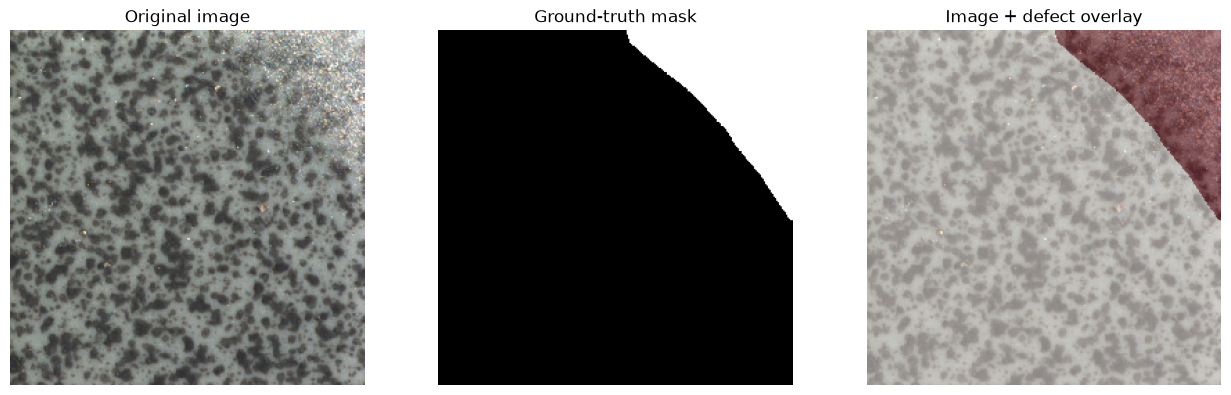

Example: 1010.png


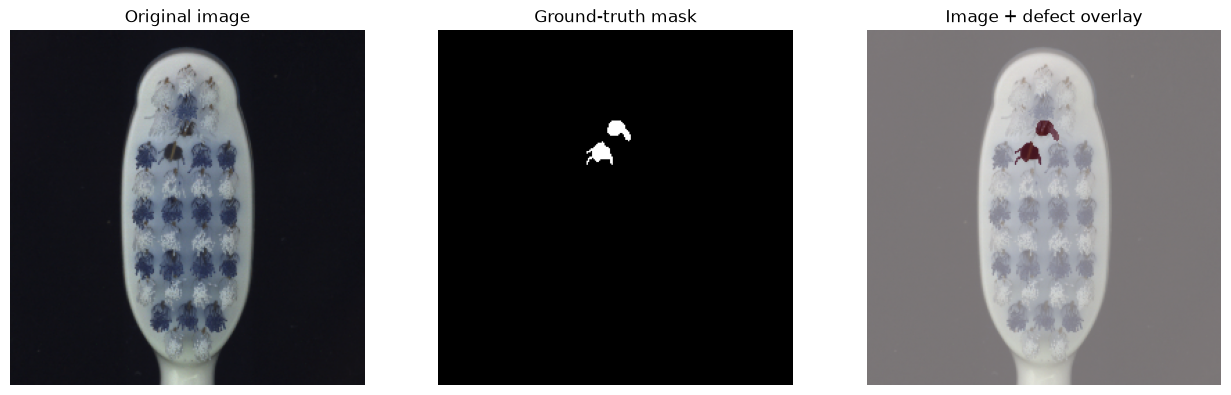

Example: 1023.png


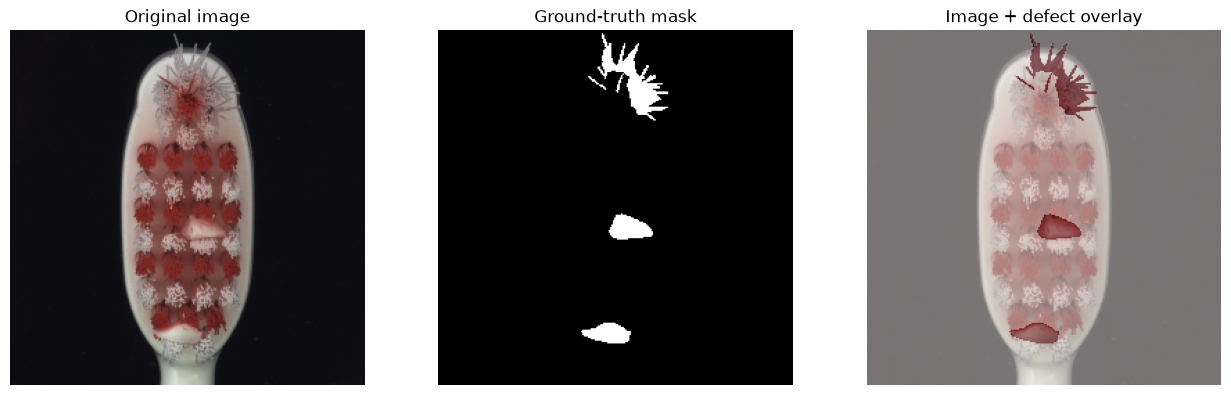

In [10]:
def find_matching_annotation(image_path, split):
    relative = image_path.relative_to(IMG_ROOT / split)
    return ANN_ROOT / split / relative

def show_image_mask_overlay(image_path, split, alpha=0.45):
    ann_path = find_matching_annotation(image_path, split)

    image = np.array(Image.open(image_path).convert("RGB"))
    mask = np.array(Image.open(ann_path))
    binary_mask = mask != 0

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(image)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground-truth mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(binary_mask, cmap="Reds", alpha=alpha)
    axes[2].set_title("Image + defect overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# Show a few test examples that actually contain a defect.
shown = 0
for image_path in image_files(IMG_ROOT / "test"):
    ann_path = find_matching_annotation(image_path, "test")
    mask = np.array(Image.open(ann_path))
    if np.any(mask != 0):
        print("Example:", image_path.name)
        show_image_mask_overlay(image_path, "test")
        shown += 1
    if shown >= 3:
        break

## 10. Visualize normal vs defective examples

This gives us an initial qualitative understanding of the anomaly-detection problem.

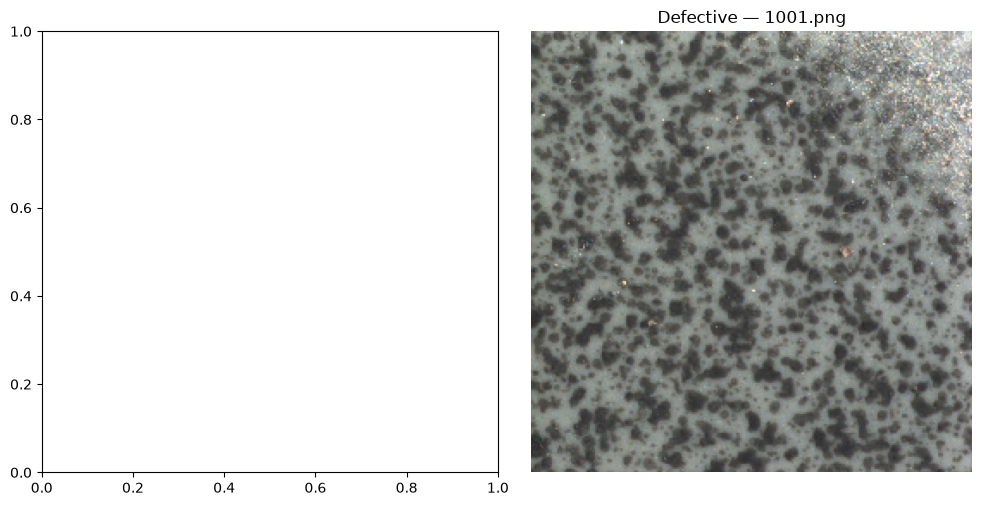

In [11]:
normal_example = None
defect_example = None

for image_path in image_files(IMG_ROOT / "test"):
    ann_path = find_matching_annotation(image_path, "test")
    mask = np.array(Image.open(ann_path))
    if np.any(mask != 0) and defect_example is None:
        defect_example = image_path
    if not np.any(mask != 0) and normal_example is None:
        normal_example = image_path
    if normal_example is not None and defect_example is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

if normal_example is not None:
    axes[0].imshow(Image.open(normal_example).convert("RGB"))
    axes[0].set_title(f"Normal — {normal_example.name}")
    axes[0].axis("off")

if defect_example is not None:
    axes[1].imshow(Image.open(defect_example).convert("RGB"))
    axes[1].set_title(f"Defective — {defect_example.name}")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## 11. Final dataset summary

This summary will be useful when we design preprocessing and the modeling experiments.

In [12]:
summary = {
    "dataset_root": str(DATA_ROOT),
    "total_images": int(sum(split_df["images"])),
    "total_annotations": int(sum(split_df["annotations"])),
    "train_images": int(split_df.loc[split_df["split"] == "train", "images"].iloc[0]),
    "val_images": int(split_df.loc[split_df["split"] == "val", "images"].iloc[0]),
    "test_images": int(split_df.loc[split_df["split"] == "test", "images"].iloc[0]),
}

pd.Series(summary, name="value")

dataset_root         C:\Documents\DefectVision\data\raw\MVTecAD-SEG
total_images                                                   1258
total_annotations                                              1258
train_images                                                    880
val_images                                                      125
test_images                                                     253
Name: value, dtype: object

## 12. Conclusions

After running this notebook, record the actual findings here rather than guessing them beforehand.

- Dataset size: **fill from output**
- Image dimensions: **fill from output**
- Train/validation/test counts: **fill from output**
- Defective vs normal distribution: **fill from output**
- Typical defect-pixel fraction: **fill from output**
- Missing image/mask pairs: **fill from output**
- Important observations: **fill from output**

These findings will determine the preprocessing strategy and the first anomaly-detection baseline.